<a href="https://colab.research.google.com/github/dhassan24/DeepLearning_For_Biology/blob/main/Chapter_3_DNA/DLFB_Chapter3_DNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ** CHAPTER 3: DNA **

## Step 1: Setup

In [1]:
#Clone the DLFB Library:

%cd /content
!rm -rf ./dlfb-clone/
!git clone "https://github.com/deep-learning-for-biology/dlfb.git" dlfb-clone --branch main
%cd dlfb-clone

/content
Cloning into 'dlfb-clone'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 129 (delta 23), reused 115 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 63.15 KiB | 9.02 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/dlfb-clone


In [2]:
#After library is cloned, install the dependencies:

%%bash
curl -LsSf https://astral.sh/uv/install.sh | sh && \
export PATH="/root/.local/bin:${PATH}" && \
uv pip compile ./requirements/{base,dlfb,dna,gpu}.txt \
  --color never \
  --constraint ./requirements/constraints.txt | \
uv pip install -r - --system

installing to /usr/local/bin
  uv
  uvx
everything's installed!


downloading uv 0.11.27 x86_64-unknown-linux-gnu
Resolved 95 packages in 3.33s
Using Python 3.12.13 environment at: /usr
Resolved 95 packages in 998ms
Prepared 54 packages in 18.30s
Uninstalled 37 packages in 610ms
Installed 54 packages in 174ms
 - absl-py==1.4.0
 + absl-py==2.5.0
 + adjusttext==1.3.0
 - aiohappyeyeballs==2.6.2
 + aiohappyeyeballs==2.7.1
 - cachetools==6.2.6
 + cachetools==7.1.4
 - certifi==2026.6.17
 + certifi==2022.12.7
 - cffi==2.0.0
 + cffi==2.1.0
 - charset-normalizer==3.4.7
 + charset-normalizer==2.1.1
 + chex==0.1.90
 - click==8.4.2
 + click==8.1.8
 + dlfb==0.1.1 (from file:///content/dlfb-clone)
 - filelock==3.29.4
 + filelock==3.29.0
 - flax==0.11.2
 + flax==0.10.4
 - fsspec==2025.3.0
 + fsspec==2026.4.0
 - google-auth==2.49.0
 + google-auth==2.55.1
 - google-cloud-storage==3.12.0
 + google-cloud-storage==3.0.0
 - humanize==4.15.0
 + humanize==4.16.0
 - idna==3.18
 + idna==3.4
 + ipinfo==5.1.1
 - jax==0.7.2
 + jax==0.5.1
 + jax-cuda12-pjrt==0.5.1
 + jax-cuda12-

In [3]:
#Access and download the necessary data:

# NOTE: exclude models with '--no-models' flag
!dlfb-provision --chapter dna

Files Downloaded: 100% 264/264 [00:04<00:00, 53.98file/s]


In [4]:
#IMport the dlfb package. The loading can sometimes be finicky; if you encounter
#issues then restart the runtime. You can re-run the load step without repeating everything

# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=False

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=False


## Building a Simple Prototype:

### The new modeling task: Binary classification; from a 200-base DNA sequence can we predict whether it binds to a specific TF, CTCF?

Reminder: CCCTC-binding factor folds DNA into loops and TADs --> regulates gene activity. The binding behavior is also easy to model b/c is has a high conserved motif with a strong sequence specificity (binding sites are more predictable than those of other TFs). Use for sequence-based models of TF binding.

In [5]:
### Loading the Labeled Sequences (Binds 0/1)

import pandas as pd
import numpy as np
from dlfb.utils.context import assets

train_df = pd.read_csv(assets("dna/datasets/CTCF_train_sequences.csv"))
train_df.head()

,sequence,label,transcription_factor,subset
0,TACCACATGAGTTCTCTTTCAGTTTGCTATGGAAGACACAAAAACC...,1,CTCF,train
1,CATCAACACTCGTGCGACGCCCTCGCATTTTCATTAATGATGGCCT...,0,CTCF,train
2,GCACACAGCGCAGGAACCTGGCACTGGAGAAGCCACCCAGGCTGTG...,1,CTCF,train
3,GCCAGCCGAAGCAGAGAGCAGTGCACATGCGTGCAGCTACCAGCAT...,1,CTCF,train
4,GTCCCGTCCCTTTTCGTGCCTCTGCCCCCACAGCTGCTGCAGTCTG...,1,CTCF,train


In [6]:
len(train_df.index)

61083

In [7]:
len(train_df[train_df["label"] == 1])

30545

In [8]:
train_df['label'].value_counts()

,count
label,
1,30545
0,30538


In [9]:
#To use DNA sequences numerically, conver them into one-hot encoded format
from dlfb.dna.utils import dna_to_one_hot
display(["import numpy as np", dna_to_one_hot])

import numpy as np

def dna_to_one_hot(dna_sequence: str) -> np.ndarray:
  """Convert DNA into a one-hot encoded format with channel ordering ACGT."""
  base_to_one_hot = {
    "A": (1, 0, 0, 0),
    "C": (0, 1, 0, 0),
    "G": (0, 0, 1, 0),
    "T": (0, 0, 0, 1),
    "N": (1, 1, 1, 1),  # N represents any unknown or ambiguous base.
  }
  one_hot_encoded = np.array([base_to_one_hot[base] for base in dna_sequence])
  return one_hot_encoded

In [10]:
#Test one-hot-encoding array with input DNA sequence:
dna_to_one_hot("AACGT")

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])

In [11]:
##Apply the ocnverter to the training dataset to generate numerical training data:

x_train = np.array(dna_to_one_hot(seq) for seq in train_df["sequence"])
y_train = train_df["label"].values[:, None] #0 = no binding CTCF, 1 = binds CTCF

In [12]:
y_train

array([[1],
       [0],
       [1],
       ...,
       [1],
       [0],
       [0]])

In [13]:
from dlfb.dna.dataset import load_dataset
display([load_dataset])

def load_dataset(sequence_db) -> dict[str, np.ndarray]:
  """Load sequences and labels from a CSV into numpy arrays."""
  df = pd.read_csv(sequence_db)
  return {
    "labels": df["label"].to_numpy()[:, None],
    "sequences": np.array([dna_to_one_hot(seq) for seq in df["sequence"]]),
  }

In [14]:
#Convert dataset into a tensorflow dataset, this format makes it easy to
#efficiently iterate over batches during model training, especially when
#shuffling and repeatin data for multiple epochs
from dlfb.dna.dataset import convert_to_tfds
display([convert_to_tfds])

def convert_to_tfds(
  dataset, batch_size: int | None = None, is_training: bool = False
):
  """Convert DNA sequences and labels to a TensorFlow dataset."""
  ds = tf.data.Dataset.from_tensor_slices(dataset)
  if is_training:
    ds = ds.shuffle(buffer_size=len(dataset["sequences"]))
    ds = ds.repeat()
  batch_size = batch_size or len(dataset["labels"])
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.experimental.AUTOTUNE)
  return ds

Create training dataset train_ds with batching, shuffling, and repetition

In [15]:
batch_size = 32

train_ds = convert_to_tfds(
    load_dataset(assets("dna/datasets/CTCF_train_sequences.csv")),
    batch_size = batch_size,
    is_training=True,
)

In [16]:
#Sanity check on batches

batch = next(train_ds.as_numpy_iterator())
print(f'Batch sequence shape: {batch["sequences"].shape}')
print(f'Batch sequence insances: {batch["sequences"][:3,:3,]}...')
print(f'Batch labels shape: {batch["labels"].shape}')
print(f'Batch labels instances: {batch["labels"][:3,]}...')

Batch sequence shape: (32, 200, 4)
Batch sequence insances: [[[0 0 0 1]
  [0 0 1 0]
  [0 0 1 0]]

 [[0 0 1 0]
  [0 0 1 0]
  [0 0 0 1]]

 [[0 1 0 0]
  [0 0 0 1]
  [0 1 0 0]]]...
Batch labels shape: (32, 1)
Batch labels instances: [[1]
 [1]
 [1]]...


Batch sequences: batch size of 32, sequence length of 200, and 4 channels per DNA base. Labels are a simply binary of 0/1 and 32 batches

In [17]:
#Validation:

valid_ds = load_dataset(assets("dna/datasets/CTCF_valid_sequences.csv"))

3.2 Define a Convolutional Model

In [18]:
from dlfb.dna.model import ConvModel
display([ConvModel], hide=[ConvModel.create_train_state])

class ConvModel(nn.Module):
  """Basic CNN model for binary sequence classification."""

  conv_filters: int = 64  # Number of filters for conv layers.
  kernel_size: tuple[int] = (10,)  # Kernel size for 1D conv layers.
  dense_units: int = 128  # Units in first dense fully-connected layer.

  @nn.compact
  def __call__(self, x):
    # First convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Second convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Flatten the values before passing them to the dense layers.
    x = x.reshape((x.shape[0], -1))

    # First dense layer.
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)

    # Second dense layer.
    x = nn.Dense(self.dense_units // 2)(x)
    x = nn.gelu(x)

    # Output layer (single unit for binary classification).
    return nn.Dense(1)(x)

In [19]:
#Instantiate the model:

model = ConvModel()

In [20]:
#Initialize model parameters in JAX by providing a dummy input tensor that matches
#expected shape of the model's inputs, use a tensor of ones with batch size of 1

import jax
import jax.numpy as jnp

dummy_input = jnp.ones((1, *batch["sequences"][1,].shape))
print(dummy_input.shape)

(1, 200, 4)


In [21]:
rng_init = jax.random.PRNGKey(42)
variables = model.init(rng_init, dummy_input)
params = variables["params"]

In [22]:
params.keys()

dict_keys(['Conv_0', 'Conv_1', 'Dense_0', 'Dense_1', 'Dense_2'])

In [23]:
for layer in params.keys():
  print(f'Layer {layer} param shape: {params[layer]["kernel"].shape}')

Layer Conv_0 param shape: (10, 4, 64)
Layer Conv_1 param shape: (10, 64, 64)
Layer Dense_0 param shape: (3200, 128)
Layer Dense_1 param shape: (128, 64)
Layer Dense_2 param shape: (64, 1)


Making predictions with the CNN model

In [24]:
import flax.linen as nn
import numpy as np

In [25]:
logits = model.apply({'params':params}, batch["sequences"])

#Apply sigmoid to convert logits to probabilities
probs = nn.sigmoid(logits)

#Print the first few predictions
print(probs[0:5])

[[0.49208623]
 [0.48603868]
 [0.48650458]
 [0.48263353]
 [0.49759477]]


Defining a Loss Function

In [26]:
#A binary cross-entropy loss function using optax library to train model parameters:

import optax

def calculate_loss(params, batch):
  """ Mark predictions on batch and compute binary cross entropy loss."""
  logits = model.apply({"params": params}, batch["sequences"])
  loss = optax.sigmoid_binary_cross_entropy(logits, batch["labels"]).mean()
  return loss

In [27]:
#Calculate loss for initial batch:

calculate_loss(params, batch)

Array(0.6958879, dtype=float32)

BINARY CROSS ENTROPY LOSS IS THE STANDARD LOSS FUNCTION FOR BINARY LABEL PREDICTIONS

Penalizes confident but incorrect predictions more heavily, encouraging well-calibrated outputs near 0 or 1. MOdel tries to approximate a hidden binary signal and cross-entropy impsoes a sharp cost for noisy/off-target estimates

#### Defining the TrainState

In [28]:
#First need to determine the optimizer, using Adam with a learning rate of 1e-3 (common default)

#Optimizer = How the model learns (updates the weights)

#Activation function = How the model becomes nonlinear (allows it to learn complex relationships)

learning_rate = 0.001
tx = optax.adam(learning_rate)

In [35]:
from flax.training.train_state import TrainState

state = TrainState.create(apply_fn = model.apply, params = params, tx = tx)

#Function to create the train state:

def create_train_state(model, rng, dummy_input, tx) -> TrainState:
  variables = model.init(rng, dummy_input)
  state = TrainState.create(
      apply_fn = model.apply, params = variables["params"], tx = tx
  )

  return state

# Defining a Single Training Step:

1. Forward Pass: Takes a batch of data, makes model predictions, and computes loss based on the current parameters

2. Backwards Pass: Computes gradients of the loss with respect to the parameters

3. Update: Using the computed gradients, updates the parameters to minimize the model loss

In [30]:
## Combine all of these steps in the train_step function:

@jax.jit
def train_step(state, batch):
  """ Run single training step to compute gradients and update model params."""
  grad_fn = jax.value_and_grad(calculate_loss, has_aux = False)
  loss, grads = grad_fn(state.params, batch)
  state = state.apply_gradients(grads = grads)
  return state, loss

In [32]:
#Run one training step:

state, loss = train_step(state, batch)

In [33]:
calculate_loss(state.params, batch)

#Before updating model params it was: Array(0.6958879, dtype=float32)

Array(0.66477305, dtype=float32)

Now run the train_step function many times to optimize the model. We train for 500 steps and periodically evaluate on the validation set:

In [36]:
import tqdm

#Reinitizlie the model state to ensure we start fresh each time cell is run.
rng_init = jax.random.PRNGKey(42)
state = create_train_state(model, rng_init, dummy_input, tx)

#Keep track of both training and validation set losses.
train_losses, valid_losses = [], []
train_batches = train_ds.as_numpy_iterator()

#Use tqdm, a progress bar.
for step in tqdm.tqdm(range(500)):
  batch = next(train_batches)
  state, loss = train_step(state, batch)
  train_losses.append({"Step": step, "Loss":loss.item()})

  #Compute loss on entire validation set every 100 steps:
  if step % 100 == 0:
    valid_loss = calculate_loss(state.params, valid_ds)
    valid_losses.append({"Step":step, "Loss":valid_loss.item()})

  losses = pd.concat(
      [
          pd.DataFrame(train_losses).assign(split="train"),
          pd.DataFrame(valid_losses).assign(split = "valid"),
      ]
  )

100%|██████████| 500/500 [01:30<00:00,  5.51it/s]


In [37]:
losses.head(20)

,Step,Loss,split
0,0,0.681982,train
1,1,0.812105,train
2,2,0.803162,train
3,3,0.677991,train
4,4,0.691434,train
5,5,0.693474,train
6,6,0.696634,train
7,7,0.688040,train
8,8,0.686419,train
9,9,0.676687,train


Plot the training and validation loss curves from the run:

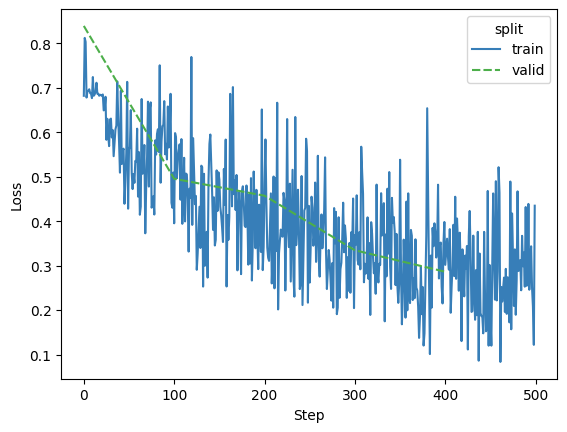

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

from dlfb.utils.metric_plots import DEFAULT_SPLIT_COLORS

sns.lineplot(
    data = losses,
    x = "Step",
    y = "Loss",
    hue = "split",
    style = "split",
    palette = DEFAULT_SPLIT_COLORS
);

Both training + validation loss decrease over learning steps, indicating that the model is learning signal in data over time. Training loss is noiser b/c it is being computed on a small batch of the data at each step (rather than full training set) --> more variability

### Sanity checking the model:

Check model has learned something sensible. Construct a 200-base-long DNA string containing repeats of the CTCF binding motif and convert into the one-hot-encoded format for our model.

In [40]:
ctcf_motif_dna = "CCACCAGGGGGCGC" * 14 + "AAAA"
print("Length of CTCF motif-filled DNA string:", len(ctcf_motif_dna))

Length of CTCF motif-filled DNA string: 200


In [42]:
ctcf_input = dna_to_one_hot(ctcf_motif_dna)[None, :]
ctcf_input.shape

(1, 200, 4)

In [47]:
#Expect that the model will precit a high probability of CTCF binign this sequence
#b/c it has relevant motif:

jax.nn.sigmoid(model.apply({"params":state.params}, ctcf_input))

Array([[0.9999771]], dtype=float32)